# Analisis Sistem Rekomendasi Collaborative Filtering (SVD vs KNN)

Dalam tugas kali ini, kita mengambil studi kasus product review dari Amazon dengan kategori produk Health and Care dengan dataset dari tahun 2023. Dimana kita akan menggunakan model Singular Value Decomposition (SVD) dan K-Nearest Neighbors (KNN) yang nanti nya akan kita analisis model mana yang cocok dalam segi performa untuk dataset yang sudah kita ambil.

**Kelompok:**
* 2311102081 - Apri Pandu Wicaksono
* 2311102051 - Muhammad Aulia Muzzaki Nugraha
* 2311101084 - Muhammad Zaki Fauzan
* 2311102117 - Alif Zaujati Randri

## Dependency Stuff

In [1]:
# Import Library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from surprise.model_selection import GridSearchCV
from surprise import Dataset, Reader, SVD, KNNBasic, accuracy
from surprise.model_selection import train_test_split
import warnings

# Mengabaikan warning agar output notebook tetap rapi
warnings.filterwarnings('ignore')

## Data Collection

In [2]:
# Load Dataset
df_raw = pd.read_json("../data/amazon_product_reviews_2023.jsonl", lines=True)
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 494121 entries, 0 to 494120
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             494121 non-null  int64         
 1   title              494121 non-null  str           
 2   text               494121 non-null  str           
 3   images             494121 non-null  object        
 4   asin               494121 non-null  str           
 5   parent_asin        494121 non-null  str           
 6   user_id            494121 non-null  str           
 7   timestamp          494121 non-null  datetime64[ms]
 8   helpful_vote       494121 non-null  int64         
 9   verified_purchase  494121 non-null  bool          
dtypes: bool(1), datetime64[ms](1), int64(2), object(1), str(5)
memory usage: 34.4+ MB


In [3]:
# Sampling data karena terlalu banyak (kita hanya mengambil 100k data)
df_sample = df_raw.sample(n=100000, random_state=42)
df_sample.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 211923 to 169424
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   rating             100000 non-null  int64         
 1   title              100000 non-null  str           
 2   text               100000 non-null  str           
 3   images             100000 non-null  object        
 4   asin               100000 non-null  str           
 5   parent_asin        100000 non-null  str           
 6   user_id            100000 non-null  str           
 7   timestamp          100000 non-null  datetime64[ms]
 8   helpful_vote       100000 non-null  int64         
 9   verified_purchase  100000 non-null  bool          
dtypes: bool(1), datetime64[ms](1), int64(2), object(1), str(5)
memory usage: 7.7+ MB


In [4]:
# Cek data sample
df_sample.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
211923,5,Highly recommend,Excellent scale... love the fact it doesn't ha...,[],B01EW9V5DK,B01EW9V5DK,AFW4XCUOK24VNSASMK6MUWPKA5TQ,2017-01-24 11:21:14.000,0,True
418640,2,Helpful for back support but not wearable as w...,I got it and was really excited to use for my ...,[],B000I5UARK,B000I5UARK,AGGMLAOP2LB7YQR7XQNZ4LYUDTSA,2011-03-01 06:28:50.000,2,True
455970,5,Product was what was expected,This product was much better than what I was u...,[],B07X4CLGBB,B07X4CLGBB,AF7US3ONGMFIZTFVPQBXGZXQPKVA,2020-02-11 14:54:45.091,0,True
394457,5,Five Stars,Great buy,[],B01C6C7C2I,B01C6C7C2I,AEA7H5QL424OTHYXMQNJFAM6KHKA,2016-10-26 15:48:02.000,0,True
142002,4,BETTER HEARING,MY WIFE SAYS THAT HER HEARING HAS IMPROVED. I ...,[],B00FT0H7F2,B00FT0H7F2,AH6QEIOD4BE4SQOUX5TWQRPXXFVA,2014-03-12 13:33:20.000,8,True


In [5]:
# Extraksi data, karena kita hanya butuh beberapa data saja
df_cf = df_sample[["user_id", "parent_asin", "rating"]]

# Ubah value rating ke number, untuk preventasi ketika dataset tidak bernilai angka
df_cf["rating"] = pd.to_numeric(df_cf["rating"], errors='coerce')
df_cf.info()

<class 'pandas.DataFrame'>
Index: 100000 entries, 211923 to 169424
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   user_id      100000 non-null  str  
 1   parent_asin  100000 non-null  str  
 2   rating       100000 non-null  int64
dtypes: int64(1), str(2)
memory usage: 3.1 MB


## Exploration Data Analysis

In [6]:
# Mengecek statistik data
display(df_cf.describe())

,rating
count,100000.000000
mean,3.986270
std,1.485006
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


In [7]:
# Melihat data unik dan jumlah interaksi (mengecek syarat dataset yaitu 100 user, 100 produk, dan 10.000 interaksi)
total_interaksi = len(df_cf)
total_user = df_cf["user_id"].nunique()
total_item = df_cf["parent_asin"].nunique()

print(f"Total Interaksi (Baris) : {total_interaksi}")
print(f"Total User Unik         : {total_user}")
print(f"Total Item Unik         : {total_item}")

# Menghitung Sparsity (Kekosongan Matriks)
kemungkinan_interaksi = total_user * total_item
sparsity = (1 - (total_interaksi / kemungkinan_interaksi)) * 100
print(f"Sparsity Matriks        : {sparsity:.4f}%")

Total Interaksi (Baris) : 100000
Total User Unik         : 97870
Total Item Unik         : 28185
Sparsity Matriks        : 99.9964%


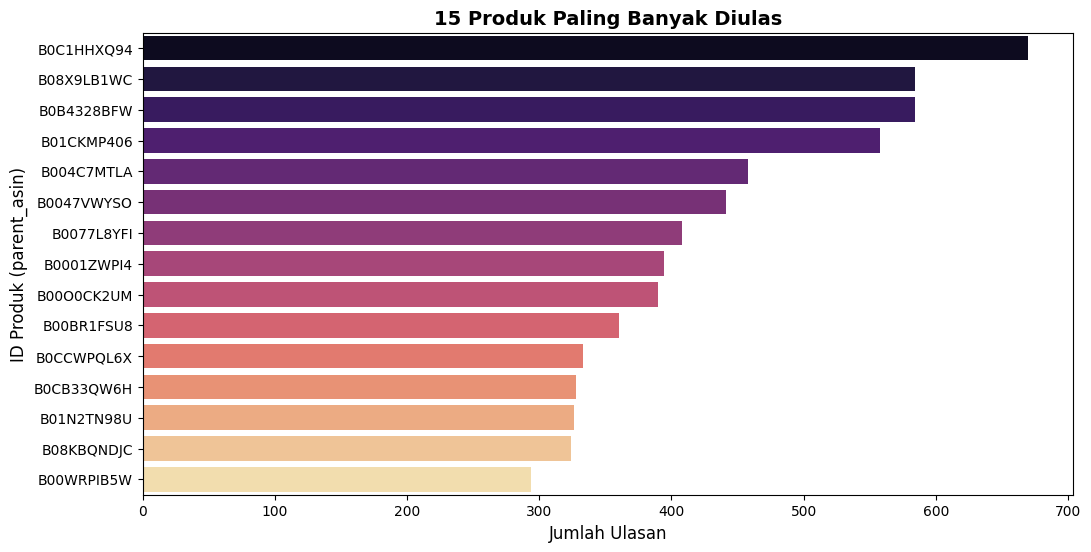

In [8]:
# Visualisasi data untuk produk yang paling banyak diulas
top_items = df_cf["parent_asin"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_items.values, y=top_items.index, palette="magma")
plt.title("15 Produk Paling Banyak Diulas", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Ulasan", fontsize=12)
plt.ylabel("ID Produk (parent_asin)", fontsize=12)
plt.show()

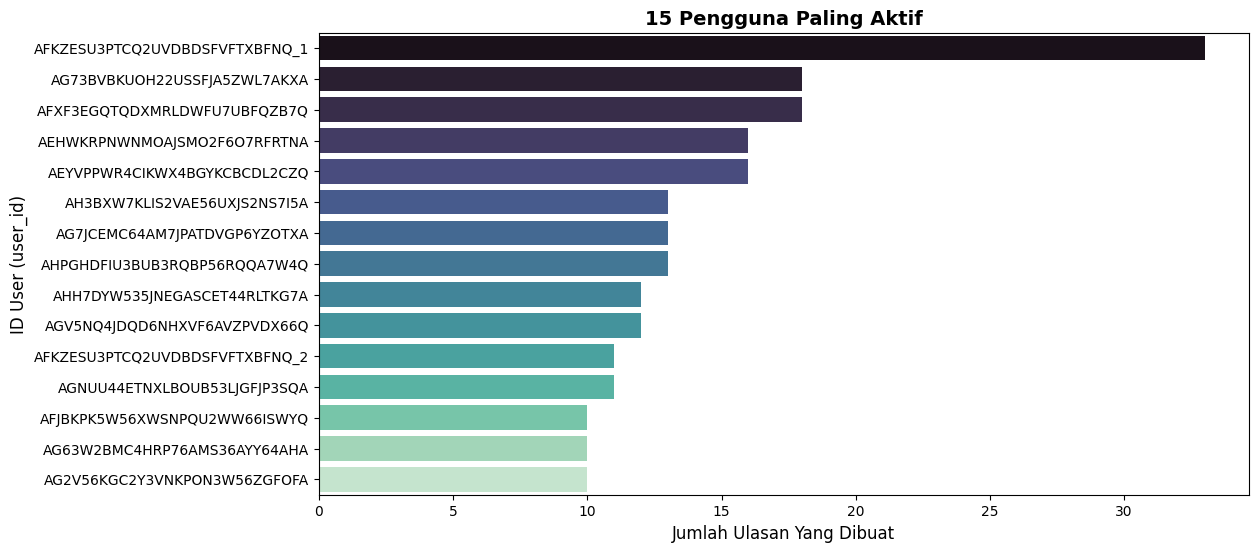

In [9]:
# Visualisasi data untuk pengguna paling banyak mengulas
top_users = df_cf["user_id"].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_users.values, y=top_users.index, palette="mako")
plt.title("15 Pengguna Paling Aktif", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Ulasan Yang Dibuat", fontsize=12)
plt.ylabel("ID User (user_id)", fontsize=12)
plt.show()

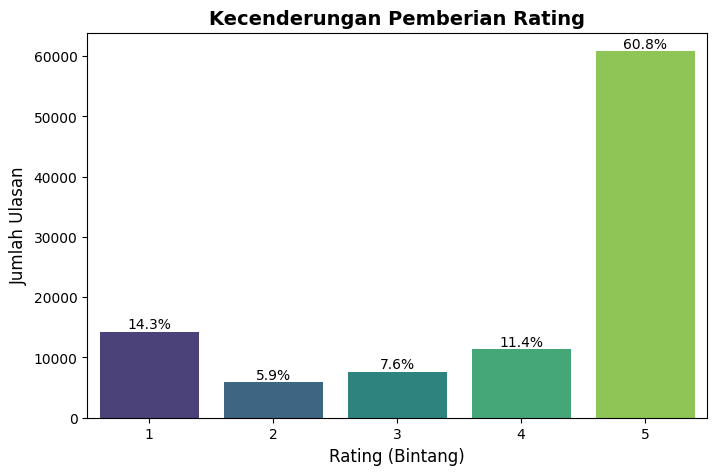

In [10]:
# Visualisasi dari distribusi data rating
plt.figure(figsize=(8, 5))
sns.countplot(x=df_cf["rating"], palette="viridis")
plt.title("Kecenderungan Pemberian Rating", fontsize=14, fontweight='bold')
plt.xlabel("Rating (Bintang)", fontsize=12)
plt.ylabel("Jumlah Ulasan", fontsize=12)

# Menambahkan persentase di atas batang grafik
total = len(df_cf["rating"])
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%' # type: ignore
    x = p.get_x() + p.get_width() / 2 # type: ignore
    y = p.get_height() # type: ignore
    plt.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

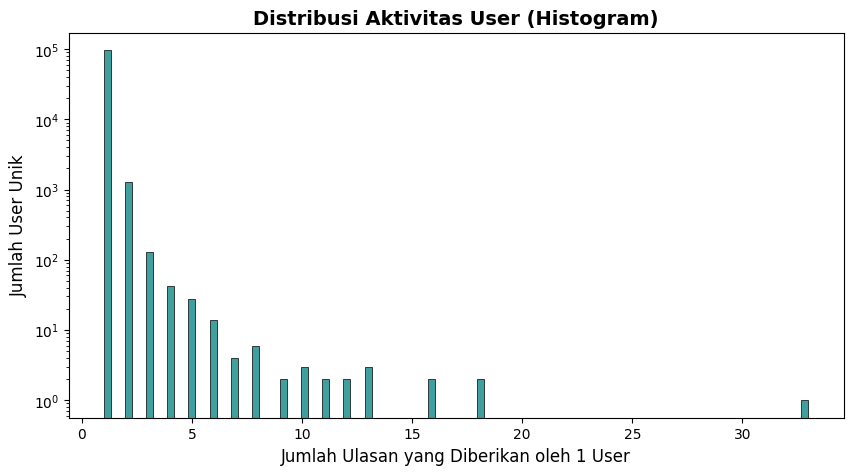

Batas Wajar Maksimal : 1.0 ulasan
Jumlah Outlier       : 1517 user


In [11]:
# Histogram untuk melakukan pengecekan outlier
user_activity = df_cf["user_id"].value_counts()

q1 = user_activity.quantile(0.25)
q3 = user_activity.quantile(0.75)
iqr = q3 - q1
batas_atas = q3 + 1.5 * iqr
jumlah_outlier = len(user_activity[user_activity > batas_atas]) # type: ignore

plt.figure(figsize=(10, 5))
sns.histplot(user_activity.values, bins=100, color="teal", kde=False) # type: ignore
plt.title("Distribusi Aktivitas User (Histogram)", fontsize=14, fontweight='bold')
plt.xlabel("Jumlah Ulasan yang Diberikan oleh 1 User", fontsize=12)
plt.ylabel("Jumlah User Unik", fontsize=12)
plt.yscale('log')
plt.show()

print(f"Batas Wajar Maksimal : {batas_atas} ulasan")
print(f"Jumlah Outlier       : {jumlah_outlier} user")

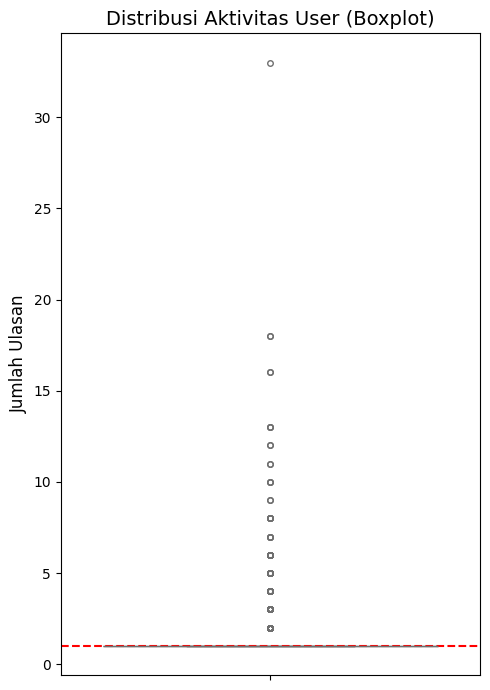

Batas Wajar Maksimal : 1.0 ulasan
Jumlah Outlier       : 1517 user


In [12]:
# Boxplot untuk melakukan pengecekan outlier
user_activity = df_cf["user_id"].value_counts()

q1 = user_activity.quantile(0.25)
q3 = user_activity.quantile(0.75)
iqr = q3 - q1
batas_atas = q3 + 1.5 * iqr
jumlah_outlier = len(user_activity[user_activity > batas_atas]) # type: ignore

plt.figure(figsize=(5, 7))
sns.boxplot(y=user_activity.values, color="skyblue", fliersize=4)
plt.axhline(y=batas_atas, color='red', linestyle='--')
plt.title("Distribusi Aktivitas User (Boxplot)", fontsize=14)
plt.ylabel("Jumlah Ulasan", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Batas Wajar Maksimal : {batas_atas} ulasan")
print(f"Jumlah Outlier       : {jumlah_outlier} user")

## Data Preprocessing

In [13]:
# Handle Missing Value

print(f"Jumlah baris awal: {len(df_cf)}")
df_cf = df_cf.dropna()
print(f"Jumlah baris setelah hapus missing value: {len(df_cf)}")

Jumlah baris awal: 100000
Jumlah baris setelah hapus missing value: 100000


In [14]:
# Hapus duplikasi data
df_cf = df_cf.groupby(["user_id", "parent_asin"])["rating"].mean().reset_index()

print(f"Jumlah baris setelah hapus duplikat: {len(df_cf)}")

Jumlah baris setelah hapus duplikat: 99715


In [15]:
# Menghapus data outlier
user_counts = df_cf["user_id"].value_counts()

q1 = user_counts.quantile(0.25)
q3 = user_counts.quantile(0.75)
batas_atas = q3 + 1.5 * (q3 - q1)

# Memfilter hanya user yang jumlah ulasannya di bawah atau sama dengan batas atas
valid_users = user_counts[user_counts <= batas_atas].index # type: ignore
df_cf = df_cf[df_cf["user_id"].isin(valid_users)]

print(f"Batas atas ulasan wajar: {batas_atas}")
print(f"Jumlah baris setelah hapus user outlier: {len(df_cf)}")

Batas atas ulasan wajar: 1.0
Jumlah baris setelah hapus user outlier: 96597


In [16]:
# Scaling data untuk menormalisasi data
scaler = MinMaxScaler(feature_range=(0, 1))
df_cf['rating_scaled'] = scaler.fit_transform(df_cf[["rating"]])

# Memastikan data siap pakai
print("Sample data setelah scaling (0-1):")
display(df_cf.head())

Sample data setelah scaling (0-1):


,user_id,parent_asin,rating,rating_scaled
0,AE222CDPBUOEJLIFR5X6KMP7YDFA,B0722M3B2H,5.0,1.00
1,AE222OUMMJSNQDOUJ5CXJ5IZ2EGQ,B0CCWPQL6X,1.0,0.00
2,AE2235F2HUZGAKOG3ON4UFZ2ZMPQ,B001DYM622,4.0,0.75
3,AE22AI2MZG45D7QOPKNMWWTBBKRA,B07FT6DBHT,5.0,1.00
4,AE22BXZWQSWGDO4A6E5GT7YLG2SQ,B06WWPTDXC,5.0,1.00


## Data Splitting

In [17]:
# Mengubah data rating ke data rating yang sudah di scaling
reader = Reader(rating_scale=(0, 1))
data = Dataset.load_from_df(df_cf[["user_id", "parent_asin", 'rating_scaled']], reader)

In [18]:
# Split data dengan catatan 20% data digunakan sebagai testing dan 80% sebagai data training
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print(f"Total Keseluruhan Data : {len(df_cf)} interaksi\n")

# Statistik data latihan
print(f"Jumlah data latih      : {trainset.n_ratings} interaksi")
print(f"Jumlah user di latih   : {trainset.n_users} user")
print(f"Jumlah item di latih   : {trainset.n_items} item\n")

# Statistik data uji
print(f"Jumlah data uji        : {len(testset)} interaksi")

Total Keseluruhan Data : 96597 interaksi

Jumlah data latih      : 77277 interaksi
Jumlah user di latih   : 77277 user
Jumlah item di latih   : 24049 item

Jumlah data uji        : 19320 interaksi


## Modeling dan Evaluasi

In [19]:
# Singular Value Decomposition (SVD)
svd_model = SVD()

# Latih model svd dengan data latihan
svd_model.fit(trainset)

# Menguji model yang sudah dilatih dengan data uji
svd_prediction = svd_model.test(testset)

# Ekstrasi nilai aktual (y_true) dan nilai tebakan (y_pred)
y_true_svd = np.array([pred.r_ui for pred in svd_prediction])
y_pred_svd = np.array([pred.est for pred in svd_prediction])

# Perhitungan untuk evaluasi
rmse_svd = accuracy.rmse(svd_prediction, verbose=False)
mae_svd = accuracy.mae(svd_prediction, verbose=False)
mse_svd = mean_squared_error(y_true_svd, y_pred_svd)
r2_svd = r2_score(y_true_svd, y_pred_svd)

print(f"RMSE        : {rmse_svd:.4f}")
print(f"MAE         : {mae_svd:.4f}")
print(f"MSE         : {mse_svd:.4f}")
print(f"R2 Score    : {r2_svd:.4f}")

RMSE        : 0.3574
MAE         : 0.2935
MSE         : 0.1277
R2 Score    : 0.0750


In [20]:
# K-Nearest Neighbors (KNN)
knn_model = KNNBasic(
    sim_options={
        "name": "cosine",
        "user_based": False
    }, verbose=False
)

# Latih model knn dengan data latihan
knn_model.fit(trainset)

# Menguji model yang sudah dilatih dengan data uji
knn_prediction = knn_model.test(testset)

# Ekstrasi nilai aktual (y_true) dan nilai tebakan (y_pred)
y_true_knn = np.array([pred.r_ui for pred in knn_prediction])
y_pred_knn = np.array([pred.est for pred in knn_prediction])

# Perhitungan untuk evaluasi
rmse_knn = accuracy.rmse(knn_prediction, verbose=False)
mae_knn = accuracy.mae(knn_prediction, verbose=False)
mse_knn = mean_squared_error(y_true_knn, y_pred_knn)
r2_knn = r2_score(y_true_knn, y_pred_knn)

print(f"RMSE        : {rmse_knn:.4f}")
print(f"MAE         : {mae_knn:.4f}")
print(f"MSE         : {mse_knn:.4f}")
print(f"R2 Score    : {r2_knn:.4f}")

RMSE        : 0.3716
MAE         : 0.3103
MSE         : 0.1381
R2 Score    : -0.0000


## Analisa Metriks

In [21]:
# Perbandingan Hasil
hasil_komparasi = pd.DataFrame({
    'Metrik Evaluasi': ['RMSE', 'MAE', 'MSE', 'R² (R-Squared)'],
    'SVD (Matrix Factorization)': [rmse_svd, mae_svd, mse_svd, r2_svd],
    'KNN Basic (Item-Based)': [rmse_knn, mae_knn, mse_knn, r2_knn]
})

display(hasil_komparasi)

,Metrik Evaluasi,SVD (Matrix Factorization),KNN Basic (Item-Based)
0,RMSE,0.357377,0.371580
1,MAE,0.293515,0.310322
2,MSE,0.127718,0.138072
3,R² (R-Squared),0.074959,-0.000028


In [22]:
# Kesimpulan analisis
rmse_best = "SVD" if rmse_svd < rmse_knn else "KNN"
r2_best = "SVD" if r2_svd > r2_knn else "KNN"

print("Kesimpulan Analisis Metrik")
print(f"1. Error Terendah (RMSE/MSE): Model {rmse_best} lebih akurat karena memiliki tingkat error prediksi yang lebih kecil.")
print(f"2. Variansi Data (R²)       : Model {r2_best} lebih baik dalam menjelaskan variansi dari data rating yang ada (semakin mendekati 1 semakin baik).")

Kesimpulan Analisis Metrik
1. Error Terendah (RMSE/MSE): Model SVD lebih akurat karena memiliki tingkat error prediksi yang lebih kecil.
2. Variansi Data (R²)       : Model SVD lebih baik dalam menjelaskan variansi dari data rating yang ada (semakin mendekati 1 semakin baik).


## Hyperparameter Tuning

In [23]:
# Tuning SVD
param_grid_svd = {
    'n_factors': [50, 100],
    'n_epochs': [20, 30],
    'lr_all': [0.002, 0.005],
    'reg_all': [0.02, 0.1]
}

gs_svd = GridSearchCV(SVD, param_grid_svd, measures=['rmse'], cv=2, n_jobs=5)
gs_svd.fit(data)

best_rmse_svd = gs_svd.best_score['rmse']
best_params_svd = gs_svd.best_params['rmse']

print(f"SVD - RMSE Terbaik: {best_rmse_svd:.4f}")
print(f"SVD - Parameter Terbaik: {best_params_svd}")

SVD - RMSE Terbaik: 0.3602
SVD - Parameter Terbaik: {'n_factors': 50, 'n_epochs': 30, 'lr_all': 0.005, 'reg_all': 0.1}


In [24]:
# Tuning KNN
param_grid_knn = {
    'k': [20, 40, 60],
    'sim_options': {
        'name': ['cosine', 'pearson'],
        'user_based': [False]
    }
}

gs_knn = GridSearchCV(KNNBasic, param_grid_knn, measures=['rmse'], cv=2, n_jobs=2)
gs_knn.fit(data)

best_rmse_knn = gs_knn.best_score['rmse']
best_params_knn = gs_knn.best_params['rmse']

print(f"KNN - RMSE Terbaik: {best_rmse_knn:.4f}")
print(f"KNN - Parameter Terbaik: {best_params_knn}")

KNN - RMSE Terbaik: 0.3729
KNN - Parameter Terbaik: {'k': 20, 'sim_options': {'name': 'cosine', 'user_based': False}}


In [25]:
# Fungsi pembantu untuk evaluasi cepat
def evaluate_final(model_class, params, trainset, testset):
    algo = model_class(**params)
    algo.fit(trainset)
    preds = algo.test(testset)
    
    y_true = np.array([p.r_ui for p in preds])
    y_pred = np.array([p.est for p in preds])
    
    rmse = accuracy.rmse(preds, verbose=False)
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

# Evaluasi kedua model dengan parameter terbaiknya
final_rmse_svd, final_r2_svd = evaluate_final(SVD, best_params_svd, trainset, testset)
final_rmse_knn, final_r2_knn = evaluate_final(KNNBasic, best_params_knn, trainset, testset)

# Menampilkan Tabel Komparasi Akhir
final_comparison = pd.DataFrame({
    'Model': ['SVD (Optimized)', 'KNN (Optimized)'],
    'RMSE Awal': [rmse_svd, rmse_knn],
    'RMSE Akhir (Tuned)': [final_rmse_svd, final_rmse_knn],
    'R² Score Akhir': [final_r2_svd, final_r2_knn]
})

display(final_comparison)

Computing the cosine similarity matrix...
Done computing similarity matrix.


,Model,RMSE Awal,RMSE Akhir (Tuned),R² Score Akhir
0,SVD (Optimized),0.357377,0.356683,0.078549
1,KNN (Optimized),0.371580,0.371580,-0.000028


## Demonstrasi

In [ ]:
target_user = df_cf["user_id"].iloc[0]
all_items = df_cf["parent_asin"].unique()
rated_items = df_cf[df_cf["user_id"] == target_user]["parent_asin"].unique()

new_items = [i for i in all_items if i not in rated_items]

preds = [svd_model.predict(target_user, i) for i in new_items]
preds.sort(key=lambda x: x.est, reverse=True)

print(f"Top 10 Rekomendasi untuk: {target_user}\n" + "-"*45)
for i, p in enumerate(preds[:10], 1):
    print(f"{i}. ID: {p.iid} | Skor: {p.est:.4f}")

Top 10 Rekomendasi untuk: AE222CDPBUOEJLIFR5X6KMP7YDFA
---------------------------------------------
1. ID: B01BZV4OPE | Skor: 1.0000
2. ID: B083T9VD7J | Skor: 1.0000
3. ID: B002NMRW7M | Skor: 1.0000
4. ID: B01NH32YAL | Skor: 1.0000
5. ID: B003DQUMJ2 | Skor: 1.0000
6. ID: B088LCFKJX | Skor: 1.0000
7. ID: B07GFJ9VDN | Skor: 1.0000
8. ID: B07259TBSQ | Skor: 1.0000
9. ID: B073DS33KY | Skor: 1.0000
10. ID: B07L4Z37WC | Skor: 1.0000


## Kesimpulan

#### Performa Model

##### SVD

Secara data memang SVD memiliki nilai akurasi yang lebih unggul jika dibandingkan dengan KNN sebagai model perbandingan, dimana hal ini dilihat dari nilai R2 yang lebih mendekati 1.0, dan SVD juga lebih ok dalam melakukan pemrosesan sparse data jika dilihat dari nilai RMSE nya.

#### KNN

Sedangkan untuk KNN sendiri unggul dalam hal interpretabilitas, dimana model dapat memberikan rekomendasi yang lebih masuk akal dalam artian merekomendasikan produk yang serupa dari inputan yang diberikan, hanya saja KNN kalah dalam segi efisiensi waktu dan memori ketika diberikan data dalam skala besar.

#### Nilai Metrik Statistik

Dari hasil modeling dan evaluasi dapat kita ambil kesimpulan dimana nilai dari R2 berdasarkan dua model yang sudah di latih memiliki nilai dibawah 0.1, dimana hal ini menunjukan bahwa data yang diberikan sangat acak dan data nya banyak namun data user yang mengulas sedikit.

#### Rekomendasi Akhir

Untuk implementasi nyata pada marketplace berdasarkan kedua model tersebut sudah jelas SVD menjadi pilihan paling baik sebagai sistem rekomendasi produk, namun jika melihat lebih luas sebetulnya kita bisa melakukan modeling dengan beberapa model lain yang sekiranya bisa mendongkrak nilai R2 sehingga dapat menghasilkan model yang lebih baik seperti XGBoost atau LightGBM.